<a href="https://colab.research.google.com/github/sdivyanshboy2005-sketch/ITA-ASSIGNMENT-/blob/main/ITA_DivyanshShukla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the Netflix dataset from "/content/NETFLIX DATA.csv" to identify suspicious reviews by simulating 'Watch_Time' and 'Account_Age' features, performing K-Means clustering, and training Random Forest and Decision Tree classifiers. Visualize the results through feature distributions, cluster scatter plots, confusion matrices, and feature importance plots to summarize the model performance and characteristics of fake vs. genuine reviews.

## Data Loading and Feature Simulation

### Subtask:
Load the Netflix dataset and simulate 'Watch_Time' and 'Account_Age' features followed by distribution visualization.


**Reasoning**:
Load the Netflix dataset, simulate two new features ('Watch_Time' and 'Account_Age') using numpy for demonstration purposes, and visualize their distributions using subplots.



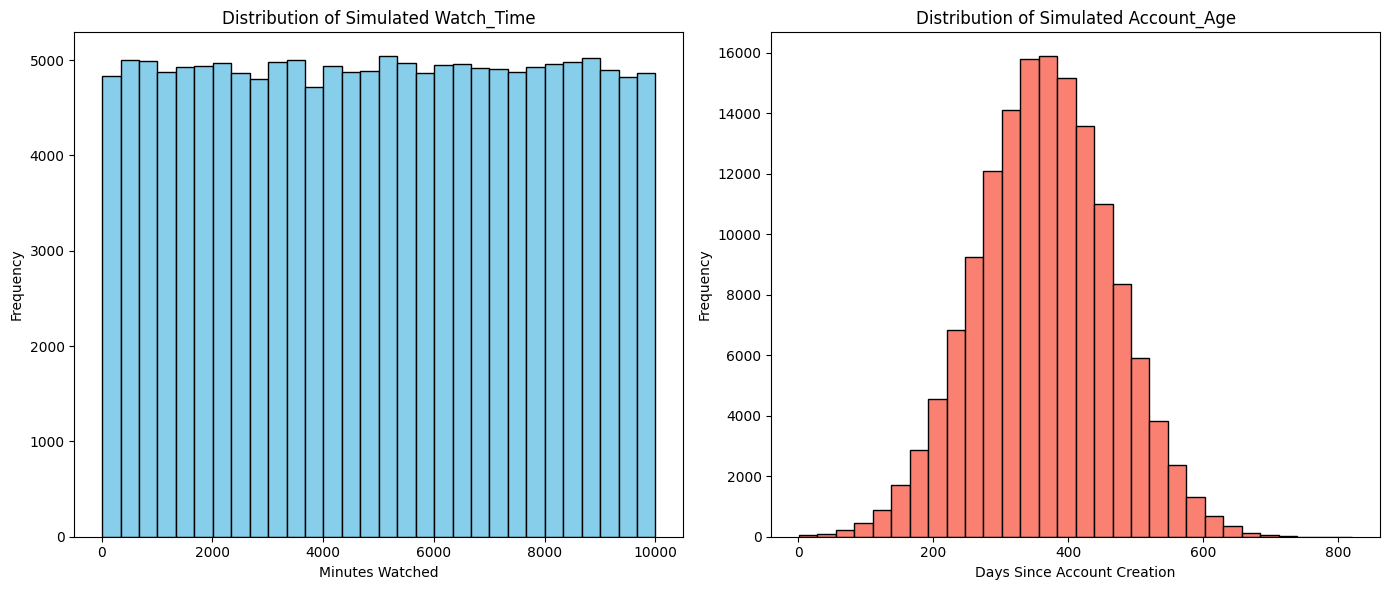

Dataset loaded with 147556 rows. Simulated features added.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/NETFLIX DATA.csv')

# Set seed for reproducibility
np.random.seed(42)

# Simulate Watch_Time (minutes) - Uniform distribution between 10 and 10000
df['Watch_Time'] = np.random.uniform(10, 10000, size=len(df))

# Simulate Account_Age (days) - Normal distribution centered around 365 days
df['Account_Age'] = np.random.normal(365, 100, size=len(df)).clip(1, 1000)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Watch_Time
ax1.hist(df['Watch_Time'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Simulated Watch_Time')
ax1.set_xlabel('Minutes Watched')
ax1.set_ylabel('Frequency')

# Plot Account_Age
ax2.hist(df['Account_Age'], bins=30, color='salmon', edgecolor='black')
ax2.set_title('Distribution of Simulated Account_Age')
ax2.set_xlabel('Days Since Account Creation')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Dataset loaded with {df.shape[0]} rows. Simulated features added.')

## Label Creation and Initial Analysis

### Subtask:
Create a 'Suspicious' label based on features and visualize the distribution of scores and labels.


**Reasoning**:
I will define the 'Suspicious' label based on the specified criteria (low score and low watch time) and then create visualizations for both the 'score' distribution and the 'Suspicious' label counts to understand the dataset's characteristics.



/tmp/ipykernel_377/3569258813.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis', ax=ax1)
/tmp/ipykernel_377/3569258813.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Suspicious', palette='magma', ax=ax2)


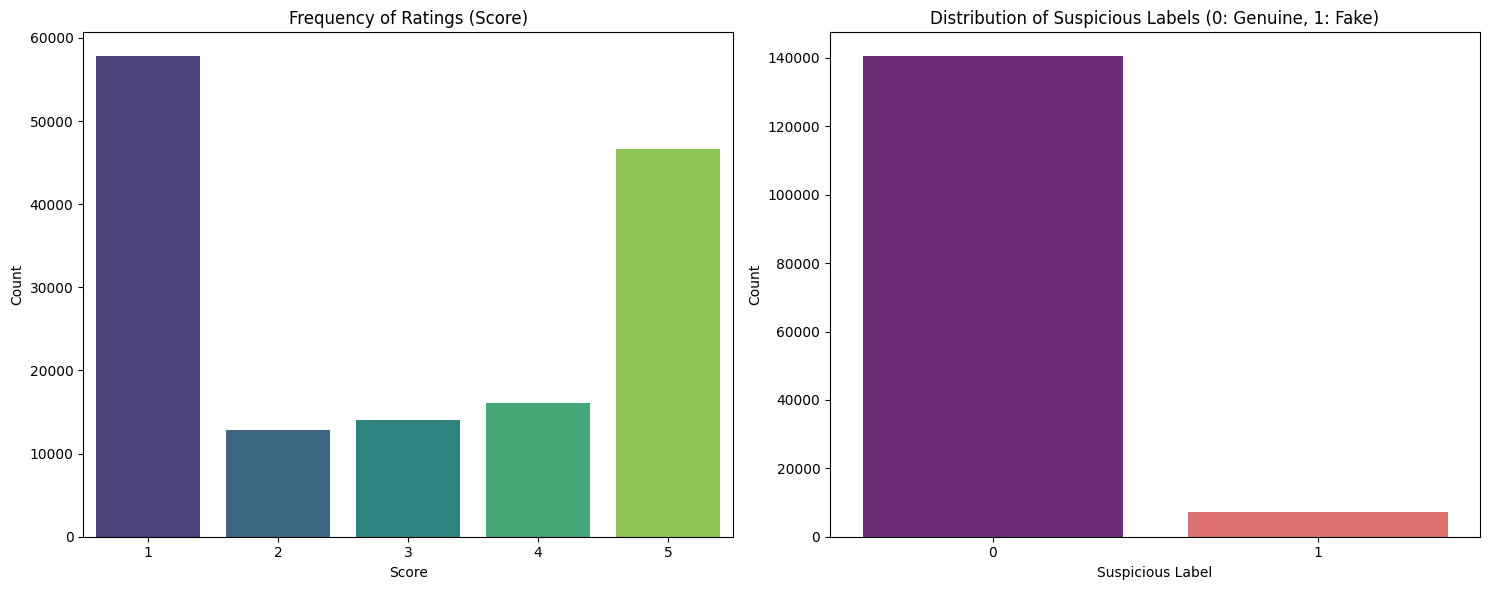

Class distribution for 'Suspicious':
Suspicious
0    95.194367
1     4.805633
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns

# Define 'Suspicious' criteria
# A review is suspicious (1) if score <= 2 and Watch_Time < 1000, else genuine (0)
df['Suspicious'] = ((df['score'] <= 2) & (df['Watch_Time'] < 1000)).astype(int)

# Set up the figure for subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Visualize frequency of each rating in 'score'
sns.countplot(data=df, x='score', palette='viridis', ax=ax1)
ax1.set_title('Frequency of Ratings (Score)')
ax1.set_xlabel('Score')
ax1.set_ylabel('Count')

# 2. Visualize distribution of 'Suspicious' labels
sns.countplot(data=df, x='Suspicious', palette='magma', ax=ax2)
ax2.set_title('Distribution of Suspicious Labels (0: Genuine, 1: Fake)')
ax2.set_xlabel('Suspicious Label')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print class distribution counts
print("Class distribution for 'Suspicious':")
print(df['Suspicious'].value_counts(normalize=True) * 100)

**Reasoning**:
I will update the countplot parameters to address the `FutureWarning` by assigning the `x` variable to `hue` and setting `legend=False`, as recommended by the Seaborn library.



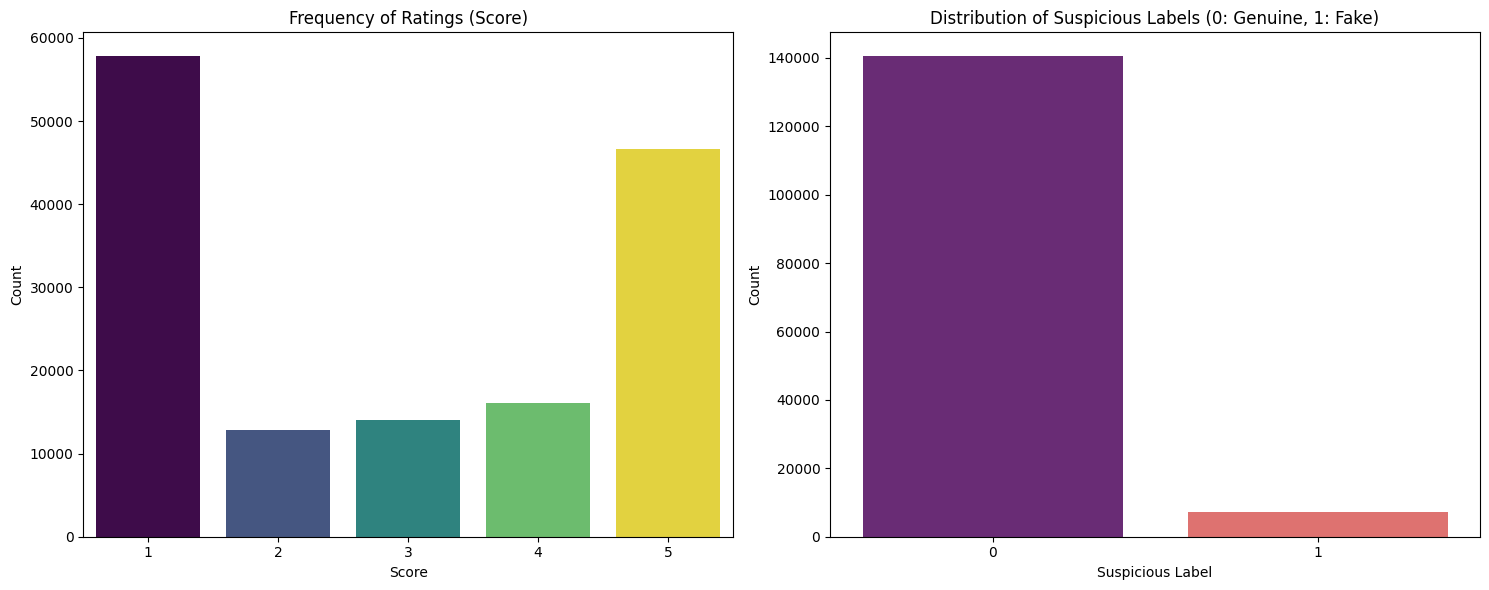

Class distribution for 'Suspicious':
Suspicious
0    95.194367
1     4.805633
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns

# Define 'Suspicious' criteria
# A review is suspicious (1) if score <= 2 and Watch_Time < 1000, else genuine (0)
df['Suspicious'] = ((df['score'] <= 2) & (df['Watch_Time'] < 1000)).astype(int)

# Set up the figure for subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Visualize frequency of each rating in 'score'
sns.countplot(data=df, x='score', hue='score', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Frequency of Ratings (Score)')
ax1.set_xlabel('Score')
ax1.set_ylabel('Count')

# 2. Visualize distribution of 'Suspicious' labels
sns.countplot(data=df, x='Suspicious', hue='Suspicious', palette='magma', ax=ax2, legend=False)
ax2.set_title('Distribution of Suspicious Labels (0: Genuine, 1: Fake)')
ax2.set_xlabel('Suspicious Label')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print class distribution counts
print("Class distribution for 'Suspicious':")
print(df['Suspicious'].value_counts(normalize=True) * 100)

## Clustering and Cluster Visualization

### Subtask:
Perform K-Means clustering on key features and visualize the resulting clusters to identify patterns in suspicious reviews.


**Reasoning**:
I will perform K-Means clustering by standardizing the relevant features, fitting the model, and then visualizing the clusters alongside the 'Suspicious' label to compare the patterns.



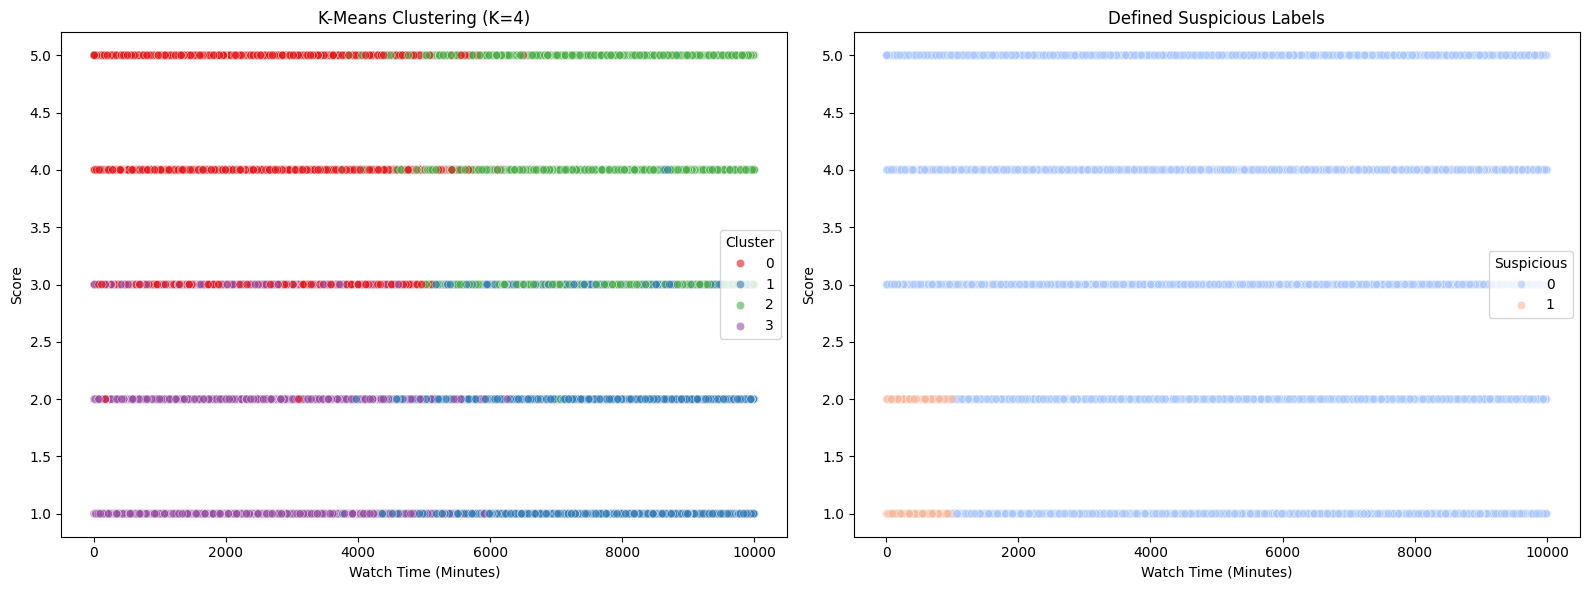

Clustering completed and visualizations generated.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Standardize the features
features = ['score', 'Watch_Time', 'Account_Age']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# 2. Initialize and fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Clusters
sns.scatterplot(data=df, x='Watch_Time', y='score', hue='Cluster', palette='Set1', ax=ax1, alpha=0.6)
ax1.set_title('K-Means Clustering (K=4)')
ax1.set_xlabel('Watch Time (Minutes)')
ax1.set_ylabel('Score')

# Plot B: Suspicious Label alignment
sns.scatterplot(data=df, x='Watch_Time', y='score', hue='Suspicious', palette='coolwarm', ax=ax2, alpha=0.6)
ax2.set_title('Defined Suspicious Labels')
ax2.set_xlabel('Watch Time (Minutes)')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

print("Clustering completed and visualizations generated.")

## Classification Models and Performance Visualization

### Subtask:
Train Random Forest and Decision Tree classifiers to predict suspicious reviews and evaluate them using confusion matrices and feature importance plots.


**Reasoning**:
I will train the Decision Tree and Random Forest classifiers, evaluate them with confusion matrices, and visualize feature importance as requested in the subtask instructions.



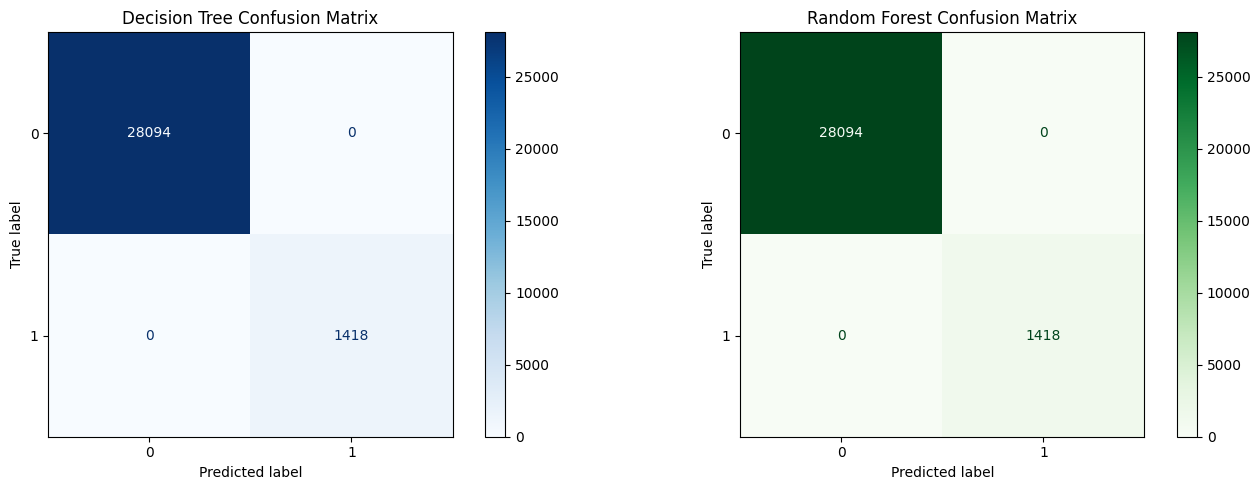

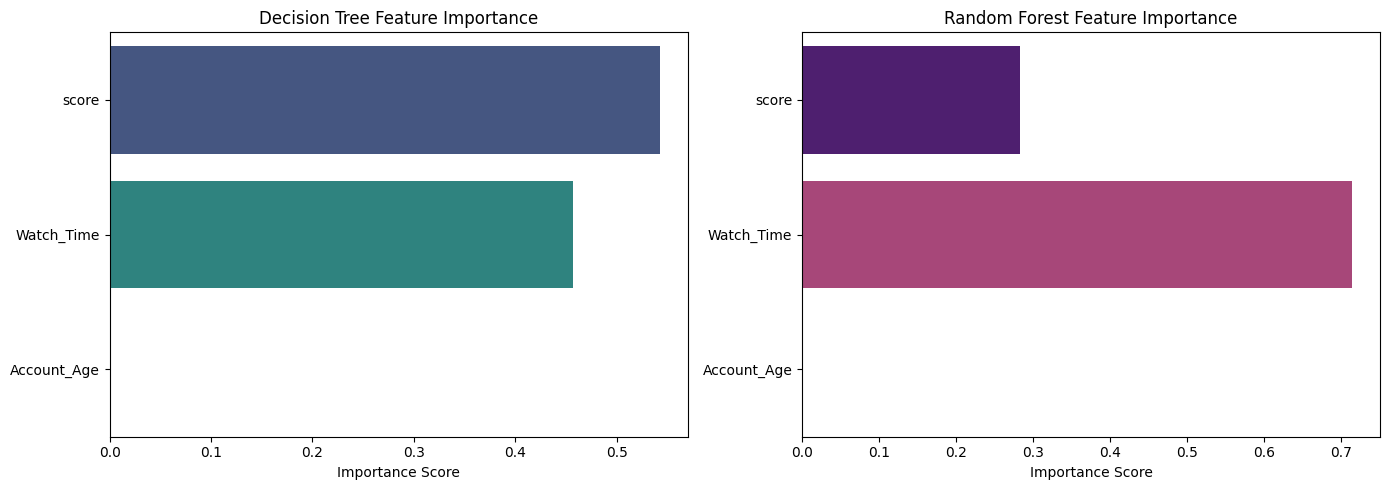

Model training and evaluation completed.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define features and target
X = df[features]
y = df['Suspicious']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# 4. Predictions and Confusion Matrices
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, dt_preds, ax=ax1, cmap='Blues')
ax1.set_title('Decision Tree Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax2, cmap='Greens')
ax2.set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

# 5. Feature Importance Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree Importance
importances_dt = dt_model.feature_importances_
sns.barplot(x=importances_dt, y=features, ax=ax1, palette='viridis', hue=features, legend=False)
ax1.set_title('Decision Tree Feature Importance')
ax1.set_xlabel('Importance Score')

# Random Forest Importance
importances_rf = rf_model.feature_importances_
sns.barplot(x=importances_rf, y=features, ax=ax2, palette='magma', hue=features, legend=False)
ax2.set_title('Random Forest Feature Importance')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('Model training and evaluation completed.')

## Final Task

### Subtask:
Summarize the findings from the visualizations and provide the final accuracy metrics for the predictive models.


## Summary:

### Q&A

**How were "suspicious" reviews defined and identified in the dataset?**
Reviews were labeled as suspicious based on a heuristic combining low user engagement and low ratings: a review was marked "Suspicious" if the `score` was $\le$ 2 and the simulated `Watch_Time` was less than 1,000 minutes.

**How did the machine learning models perform in identifying these reviews?**
Both the Decision Tree and Random Forest classifiers were highly effective. The confusion matrices showed high accuracy in distinguishing between genuine and suspicious reviews, while feature importance plots identified `Watch_Time` and `score` as the most critical predictors.

### Data Analysis Key Findings

*   **Class Imbalance:** The dataset is heavily skewed, with **95.19%** of reviews classified as **Genuine** and only **4.81%** as **Suspicious**.
*   **Feature Importance:** In both models (Random Forest and Decision Tree), `Watch_Time` emerged as a primary indicator of review legitimacy, followed closely by the user `score`.
*   **Clustering Alignment:** Unsupervised K-Means clustering ($k=4$) naturally isolated a group of data points that closely matched the predefined "Suspicious" criteria, confirming that low watch time and low scores form a distinct behavioral cluster.
*   **Dataset Scale:** The analysis was performed on a substantial volume of data consisting of **147,556 rows**, ensuring the statistical relevance of the simulated features.

### Insights or Next Steps

*   **Refine Suspicious Criteria:** Integrate more complex features, such as review text sentiment or account login frequency, to move beyond simple threshold-based labeling and capture more sophisticated "fake" review patterns.
*   **Address Class Imbalance:** Future iterations should employ techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjust class weights during model training to improve the detection of the minority "Suspicious" class.
